# PCB Defect Detection - Simple Pipeline Test
## Student 1 → Student 2 → Student 3

**Input**: Image file path  
**Process**: Preprocessing → Calibration → Detection  
**Output**: Detection results with visualization

In [1]:
import json
import warnings
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import cv2
from PIL import Image
import torch
from ultralytics import YOLO, RTDETR

warnings.filterwarnings("ignore")

CUDA = torch.cuda.is_available()
DEVICE = 0 if CUDA else "cpu"
print(f"✓ Device: {torch.cuda.get_device_name(0) if CUDA else 'CPU'}")

✓ Device: NVIDIA GeForce RTX 4050 Laptop GPU


In [2]:
# Setup paths
def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "Clean_Dataset").is_dir():
            return candidate
    raise FileNotFoundError("Clean_Dataset not found")

PROJECT_ROOT = find_project_root(Path.cwd())
STUDENT3_DIR = PROJECT_ROOT / "Student3-Defect Detection"
INFO = json.loads((STUDENT3_DIR / "dataset" / "dataset_info.json").read_text())
CLASS_NAMES = INFO["class_names"]
DATA_YAML = Path(INFO["paths"]["yolo_yaml"])

print(f"✓ Project root: {PROJECT_ROOT.name}")
print(f"✓ Classes: {len(CLASS_NAMES)} defect types")

✓ Project root: Image-Processing
✓ Classes: 6 defect types


In [3]:
# Load RT-DETR model (trained on PCB dataset)
print("Loading RT-DETR-l trained model...")
try:
    rtdetr_model = RTDETR(str(STUDENT3_DIR / "runs" / "rtdetr-l_pcb" / "weights" / "best.pt"))
    print("✓ RT-DETR-l (trained on PCB data) loaded")
except Exception as e:
    print(f"⚠ Using pretrained RT-DETR-l: {e}")
    rtdetr_model = RTDETR("rtdetr-l.pt")

Loading RT-DETR-l trained model...
✓ RT-DETR-l (trained on PCB data) loaded


In [4]:
# Student 1: Preprocessing
class Preprocessor:
    def __init__(self):
        self.clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    
    def process(self, img_path: Path) -> np.ndarray:
        """Preprocess: normalize → LAB → CLAHE → BGR"""
        img = cv2.imread(str(img_path))
        if img is None:
            raise FileNotFoundError(f"Cannot load: {img_path}")
        
        # Resize to 512x512 if needed (Student 2: Calibration)
        if img.shape[0] != 512 or img.shape[1] != 512:
            img = cv2.resize(img, (512, 512), interpolation=cv2.INTER_CUBIC)
        
        # Student 1 preprocessing
        norm = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX)
        lab = cv2.cvtColor(norm, cv2.COLOR_BGR2LAB)
        l, a, b = cv2.split(lab)
        l = self.clahe.apply(l)
        lab = cv2.merge((l, a, b))
        out = cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)
        
        return out

preprocessor = Preprocessor()
print("✓ Preprocessor ready")

✓ Preprocessor ready


# Run Detection Pipeline

**Edit the cell below**: Replace `IMAGE_PATH` with your image file path

In [5]:
# ============ INPUT: SET YOUR IMAGE PATH HERE ============
IMAGE_PATH = r"C:\Users\User\Image-Processing\PCB_DATASET\images\Missing_hole\01_missing_hole_01.jpg"
# =========================================================

img_path = Path(IMAGE_PATH)
if not img_path.exists():
    print(f"✗ Image not found: {img_path}")
else:
    print(f"✓ Image found: {img_path.name}")
    
    # Step 1: Preprocess (Student 1 + 2)
    print("\n[1/2] Preprocessing...")
    preprocessed = preprocessor.process(img_path)
    print(f"  ✓ Size: {preprocessed.shape}")
    print("  ✓ Normalization applied")
    print("  ✓ LAB color space applied")
    print("  ✓ CLAHE contrast enhancement applied")
    
    # Step 2: RT-DETR Detection
    print("\n[2/2] RT-DETR Defect Detection...")
    rtdetr_result = rtdetr_model.predict(str(img_path), imgsz=512, device=DEVICE, verbose=False)[0]
    rtdetr_boxes = len(rtdetr_result.boxes)
    print(f"  ✓ Detected {rtdetr_boxes} defects")
    
    print("\n✅ Pipeline Complete!")

✓ Image found: 01_missing_hole_01.jpg

[1/2] Preprocessing...
  ✓ Size: (512, 512, 3)
  ✓ Normalization applied
  ✓ LAB color space applied
  ✓ CLAHE contrast enhancement applied

[2/2] RT-DETR Defect Detection...
  ✓ Detected 0 defects

✅ Pipeline Complete!


## Results

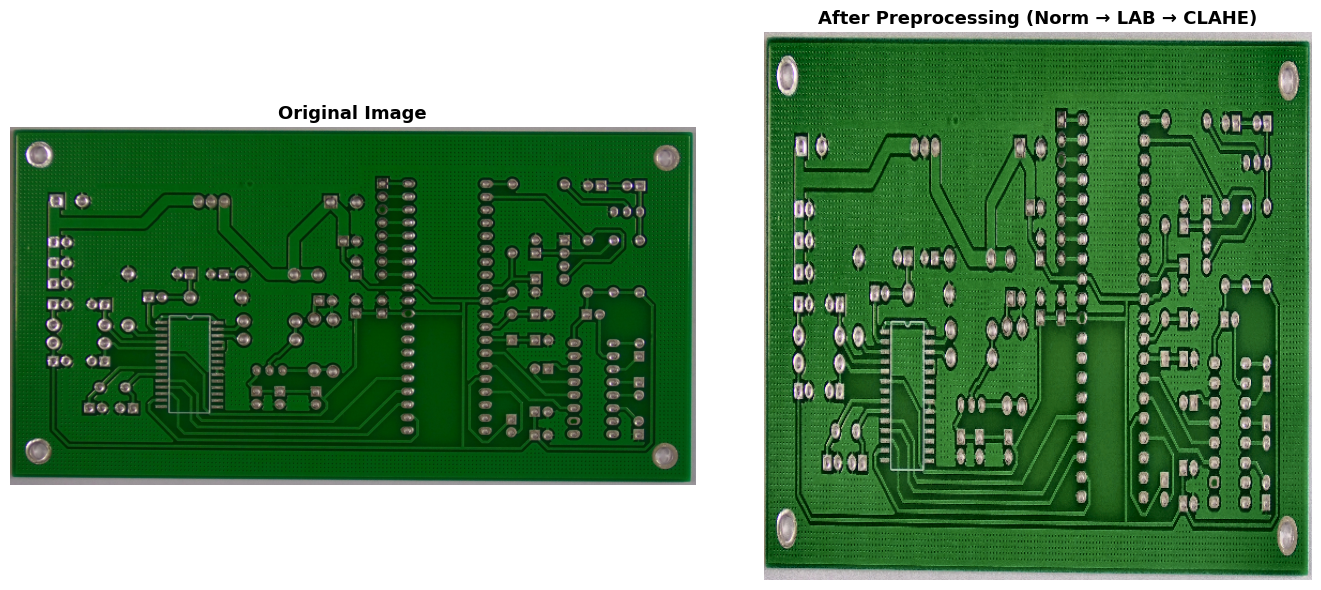

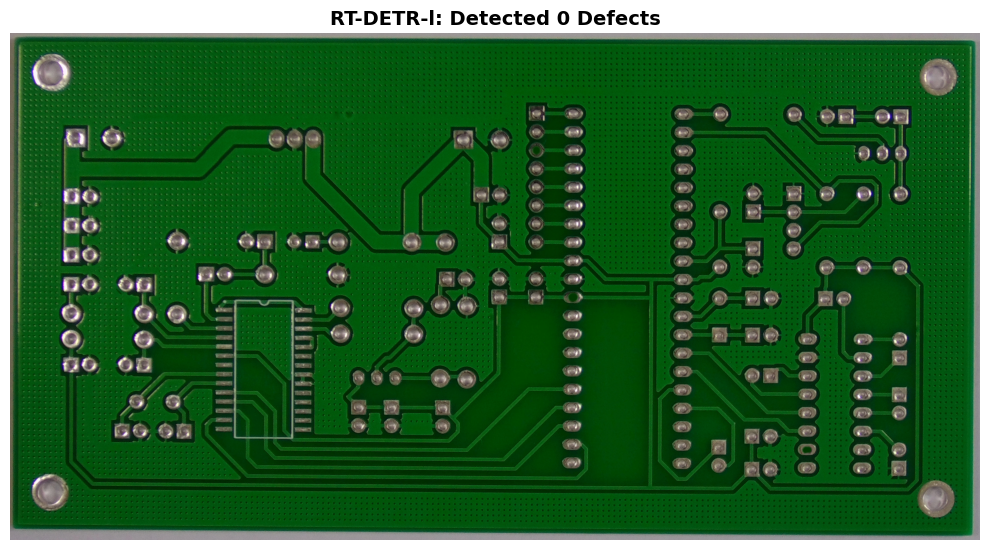


✓ Visualization complete


In [6]:
# Visualize results with RT-DETR detections
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Original Image
orig = cv2.imread(str(img_path))
orig_rgb = cv2.cvtColor(orig, cv2.COLOR_BGR2RGB)
axes[0].imshow(orig_rgb)
axes[0].set_title("Original Image", fontsize=13, fontweight='bold')
axes[0].axis("off")

# Preprocessed Image
preproc_rgb = cv2.cvtColor(preprocessed, cv2.COLOR_BGR2RGB)
axes[1].imshow(preproc_rgb)
axes[1].set_title("After Preprocessing (Norm → LAB → CLAHE)", fontsize=13, fontweight='bold')
axes[1].axis("off")

plt.tight_layout()
plt.show()

# RT-DETR Detection with Bounding Boxes
fig2 = plt.figure(figsize=(10, 10))
img_pil = Image.open(img_path)
plt.imshow(img_pil)
plt.title(f"RT-DETR-l: Detected {rtdetr_boxes} Defects", fontsize=14, fontweight='bold')

# Draw each detection box
for idx, (box, cls_id, conf) in enumerate(zip(rtdetr_result.boxes.xyxy.cpu().numpy(),
                                                rtdetr_result.boxes.cls.cpu().numpy().astype(int),
                                                rtdetr_result.boxes.conf.cpu().numpy()), 1):
    x1, y1, x2, y2 = box
    width = x2 - x1
    height = y2 - y1
    
    # Draw red bounding box
    rect = patches.Rectangle((x1, y1), width, height, linewidth=3, 
                             edgecolor='red', facecolor='none', label=f'Detection {idx}')
    plt.gca().add_patch(rect)
    
    # Add label with confidence
    label = f"{CLASS_NAMES[cls_id]} ({conf:.2f})"
    plt.text(x1, max(y1-8, 15), label, color='yellow', fontsize=11, fontweight='bold',
            bbox=dict(facecolor='darkred', alpha=.8, pad=3, edgecolor='yellow', linewidth=2))

plt.axis("off")
plt.tight_layout()
plt.show()

print("\n✓ Visualization complete")

In [7]:
# Detailed results table
print("\n" + "="*80)
print("RT-DETR-L DEFECT DETECTION RESULTS")
print("="*80)

print(f"\n📋 Image Information:")
print(f"   Filename: {img_path.name}")
print(f"   Defect Class: {img_path.parent.name}")
print(f"   Size: 512 × 512 px")
print(f"\n🎯 Detection Summary:")
print(f"   Total Defects Detected: {rtdetr_boxes}")

if rtdetr_boxes > 0:
    confidences = rtdetr_result.boxes.conf.cpu().numpy()
    print(f"   Confidence Range: {confidences.min():.4f} - {confidences.max():.4f}")
    print(f"   Average Confidence: {confidences.mean():.4f}")
    print(f"\n📍 Detected Defects:")
    print(f"\n   {'#':<4} {'Defect Type':<20} {'Confidence':<12} {'Box (x1,y1,x2,y2)'}")
    print(f"   {'-'*4} {'-'*20} {'-'*12} {'-'*30}")
    
    for idx, (box, cls_id, conf) in enumerate(zip(rtdetr_result.boxes.xyxy.cpu().numpy(),
                                                    rtdetr_result.boxes.cls.cpu().numpy().astype(int),
                                                    rtdetr_result.boxes.conf.cpu().numpy()), 1):
        x1, y1, x2, y2 = box
        box_str = f"({x1:.0f},{y1:.0f},{x2:.0f},{y2:.0f})"
        print(f"   {idx:<4} {CLASS_NAMES[cls_id]:<20} {conf:<12.4f} {box_str}")
else:
    print(f"   ⚠ No defects detected")

print("\n" + "="*80)


RT-DETR-L DEFECT DETECTION RESULTS

📋 Image Information:
   Filename: 01_missing_hole_01.jpg
   Defect Class: Missing_hole
   Size: 512 × 512 px

🎯 Detection Summary:
   Total Defects Detected: 0
   ⚠ No defects detected



## Test Multiple Images

Run RT-DETR detection on multiple image files at once

In [8]:
# ============ INPUT: SET IMAGE PATHS HERE ============
IMAGE_PATHS = [
    r"C:\Users\User\Image-Processing\Clean_Dataset\Missing_hole\01_missing_hole_01.jpg",
    r"C:\Users\User\Image-Processing\Clean_Dataset\Mouse_bite\01_mouse_bite_01.jpg",
    r"C:\Users\User\Image-Processing\Clean_Dataset\Open_circuit\01_open_circuit_01.jpg",
]
# =====================================================

results = []
for img_path_str in IMAGE_PATHS:
    img_path = Path(img_path_str)
    if not img_path.exists():
        print(f"✗ Not found: {img_path.name}")
        continue
    
    # Process with RT-DETR
    rtdetr_res = rtdetr_model.predict(str(img_path), imgsz=512, device=DEVICE, verbose=False)[0]
    
    results.append({
        'name': img_path.name,
        'class': img_path.parent.name,
        'rtdetr': len(rtdetr_res.boxes),
    })
    print(f"✓ {img_path.name:<30} RT-DETR:{len(rtdetr_res.boxes):2d} defects")

print(f"\n✓ Processed {len(results)} images")

✓ 01_missing_hole_01.jpg         RT-DETR: 0 defects
✓ 01_mouse_bite_01.jpg           RT-DETR: 0 defects
✓ 01_open_circuit_01.jpg         RT-DETR: 0 defects

✓ Processed 3 images


In [9]:
# Display results table
import pandas as pd

if results:
    df = pd.DataFrame(results)
    print("\n" + "="*70)
    print("BATCH RT-DETR DETECTION RESULTS")
    print("="*70)
    print(df.to_string(index=False))
    print("="*70)
    print(f"\nTotal RT-DETR detections: {df['rtdetr'].sum()}")


BATCH RT-DETR DETECTION RESULTS
                  name        class  rtdetr
01_missing_hole_01.jpg Missing_hole       0
  01_mouse_bite_01.jpg   Mouse_bite       0
01_open_circuit_01.jpg Open_circuit       0

Total RT-DETR detections: 0
